In [1]:
import pandas as pd
df = pd.read_csv("TelcoCustomerChurn.csv")
df.shape

(7043, 21)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


The dataset contains 7,043 customers and 21 columns. Three observations identified.
1. TotalCharges was stored as text instead of a numeric field because 11 rows contained blank spaces. 
2. there were no other missing values or duplicate records, and each customer had a unique customerID.
3. The target variable, Churn, is also imbalanced: around 73% of customers did not churn, while about 27% did. Because of this imbalance, accuracy alone would not be a reliable measure of model performance.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())


Missing TotalCharges after conversion: 11


In [6]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


The 11 blank values in TotalCharges were investigated and found to belong to customers with a tenure of 0. These are new customers who have not yet received their first bill.
For this reason, the missing TotalCharges values were replaced with 0. This is more meaningful than dropping the records or filling them with an average, since these customers genuinely have no previous charges.

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing after fill:", df['TotalCharges'].isnull().sum())

Missing after fill: 0


In [8]:
df = df.drop('customerID', axis=1)
df.shape

(7043, 20)

In [9]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [
    col for col in df.columns
    if col not in numerical_features + ['Churn']
]

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)
print("Count categorical:", len(categorical_features))

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count categorical: 16


In [10]:
categorical_features.remove('SeniorCitizen')
print("Categorical:", categorical_features)
print("Count:", len(categorical_features))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 15


Categorical variables were converted into numerical values using one-hot encoding.
For example, the Contract feature is converted into separate columns representing month-to-month, one-year, and two-year contracts, with each column containing 0 or 1 values.
The encoder was also configured to ignore previously unseen categories. This ensures that the prediction API continues to work even if new customer data contains a category that was not present during model training.
The dataset was divided into 70% training data and 30% testing data.
A random_state of 42 was used so that the same split can be reproduced consistently.
Stratified sampling was also applied to maintain the original churn distribution of approximately 27% in both the training and test datasets. This provides a more reliable basis for evaluating the model.
To avoid data leakage, the dataset was split into training and test sets before applying any encoding or scaling.
All preprocessing steps were then included in a single scikit-learn Pipeline, which is fitted only on the training data. This prevents information from the test dataset from influencing the preprocessing or model training process.
Using a pipeline also ensures that the same preprocessing steps are automatically applied to new customer data during prediction.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

/tmp/ipykernel_1598/102897697.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


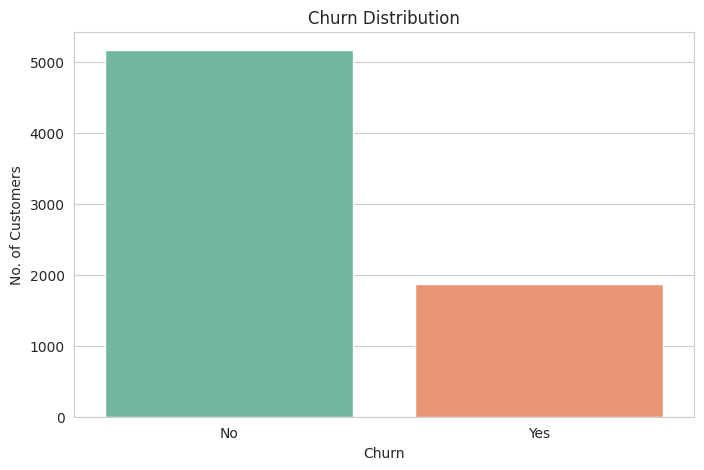

In [12]:
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.ylabel('No. of Customers')
plt.show()

Around 27% of customers churned, while 73% stayed. Because the dataset is imbalanced, accuracy alone can be misleading. 
For example, predicting “no churn” for every customer would still give about 73% accuracy while failing to identify any customers at risk of leaving.

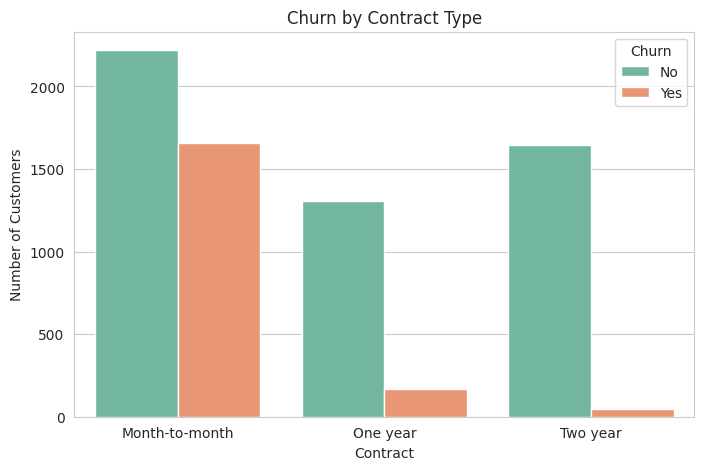

In [13]:
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Customers on month-to-month contracts have a much higher churn rate than those on one- or two-year contracts. This suggests that longer-term contracts are associated with better retention and could be explored as part of the retention strategy.

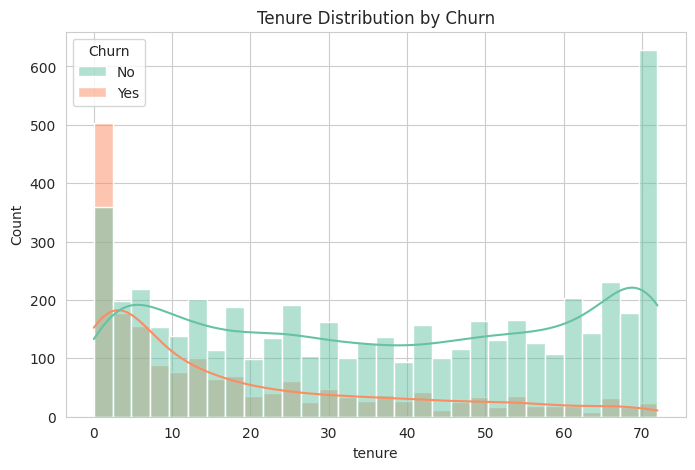

In [14]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.show()

Churn is highest among customers in the early months of their relationship with the company. Customers who remain for longer periods are less likely to churn, highlighting the importance of onboarding and early customer engagement.

/tmp/ipykernel_1598/1830928340.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


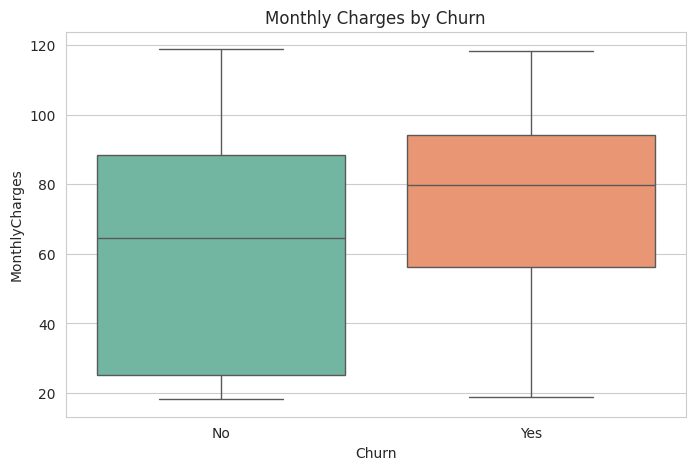

In [15]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.show()

Customers who churn generally have higher monthly charges. This suggests that pricing may be an important factor and that customers with higher bills could be considered for plan reviews or targeted retention offers.

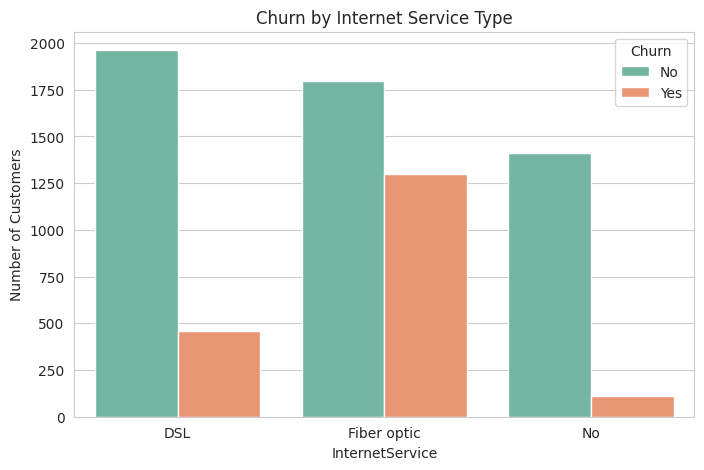

In [16]:
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

Fiber-optic customers show a noticeably higher churn rate than DSL or customers without internet service. This could indicate factors related to pricing, service quality, or customer expectations

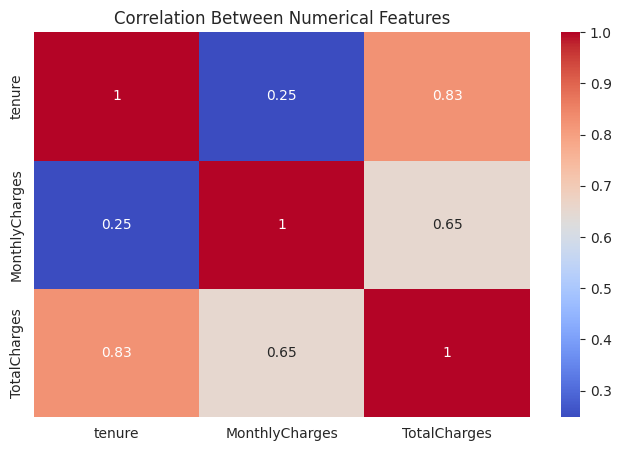

In [17]:
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numerical Features')
plt.show()

tenure and TotalCharges are strongly correlated, which is expected because customers who stay longer naturally accumulate higher total charges.

In [18]:

def tenure_bucket(months):
    if months <= 12:
        return '0-1 year'
    elif months <= 24:
        return '1-2 years'
    elif months <= 48:
        return '2-4 years'
    else:
        return '4+ years'

df['tenure_group'] = df['tenure'].apply(tenure_bucket)
df['tenure_group'].value_counts()

,count
tenure_group,
4+ years,2239
0-1 year,2186
2-4 years,1594
1-2 years,1024


In [19]:
# Count how many add-on services each customer has
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['total_services'] = df[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)
df['total_services'].value_counts().sort_index()

,count
total_services,
0,80
1,1701
2,1188
3,965
4,922
5,908
6,676
7,395
8,208


In [20]:

df['avg_monthly_value'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
df[['tenure', 'TotalCharges', 'avg_monthly_value']].head()

,tenure,TotalCharges,avg_monthly_value
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


Feature 1 — Tenure Group:
Customer tenure was grouped into four ranges: 0–1 year, 1–2 years, 2–4 years, and 4+ years. The exploratory analysis showed that churn is more common during the early stages of the customer relationship. Creating tenure groups helps the model capture this pattern more clearly by treating new customers as a distinct risk group rather than assuming churn changes smoothly with every additional month.

Feature 2 — Total Services:
This feature counts the number of services a customer actively uses, including phone service, multiple lines, streaming movies etc. Customers using more services may be more engaged with the company and potentially less likely to switch. Combining several service-related columns into a single count gives the model a simpler measure of overall customer engagement.

Feature 3 — Average Monthly Value:
This feature was calculated by dividing TotalCharges by tenure. It helps distinguish between customers who accumulated high charges over several years and those who reached similar spending levels within a much shorter period. This provides an additional view of customer spending behavior that is not fully captured by MonthlyCharges or TotalCharges alone.

In [21]:
categorical_features.append('tenure_group')
numerical_features.append('total_services')
numerical_features.append('avg_monthly_value')

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'avg_monthly_value']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [22]:
from sklearn.model_selection import train_test_split

# X = all the input columns; y = the thing we predict
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1})
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X shape: (7043, 22)
y distribution:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y

)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train: (4930, 22)  Test: (2113, 22)
Train churn rate: 0.265
Test churn rate: 0.265


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[

        ('num', StandardScaler(), numerical_features),

        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Model A: depth limited to prevent overfitting
model_a = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        random_state=42
    ))
])

model_a.fit(X_train, y_train)
print("Model A trained.")

Model A trained.


In [26]:
# Model B: deeper more flexible (more prone to overfitting)
model_b = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=None,
        min_samples_leaf=1,
        random_state=42
    ))
])

model_b.fit(X_train, y_train)
print("Model B trained.")

Model B trained.


In [27]:
from sklearn.metrics import accuracy_score, f1_score

for name, model in [('Model A (depth=5)', model_a), ('Model B (unlimited)', model_b)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    test_f1   = f1_score(y_test, model.predict(X_test))
    print(f"{name}")
    print(f"  Train accuracy: {train_acc:.3f}")
    print(f"  Test accuracy:  {test_acc:.3f}")
    print(f"  Test F1 (churn):{test_f1:.3f}")
    print()

Model A (depth=5)
  Train accuracy: 0.801
  Test accuracy:  0.794
  Test F1 (churn):0.608

Model B (unlimited)
  Train accuracy: 0.998
  Test accuracy:  0.724
  Test F1 (churn):0.486



Model A was depth-limited (max_depth=5, min_samples_leaf=50), while Model B was left unconstrained (max_depth=None, min_samples_leaf=1).

Model A: Training accuracy is 0.801 and test accuracy is 0.794. Since the two scores are very close, the model appears to generalize well to unseen data with little sign of overfitting.

Model B: Training accuracy is 0.998, while test accuracy drops to 0.724. This large gap indicates strong overfitting. The model performs almost perfectly on the training data but struggles to maintain that performance on new data.

In [28]:
final_model = model_a

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1552
       Churn       0.61      0.60      0.61       561

    accuracy                           0.79      2113
   macro avg       0.74      0.73      0.73      2113
weighted avg       0.79      0.79      0.79      2113



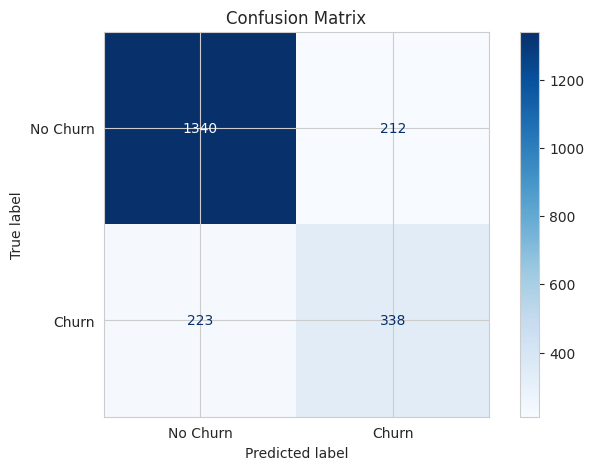

In [30]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

For a telecom churn model, Recall should be prioritized because missing an actual churner is usually more costly than incorrectly flagging a loyal customer.

A false negative means the model fails to identify a customer who later leaves, resulting in lost revenue and a missed opportunity to intervene. A false positive, on the other hand, may only lead to a relatively low-cost retention action such as a discount, email, or courtesy call.

Because the cost of missing a genuine churner is higher, the model should aim to identify as many actual churners as possible, even if this results in some false positives.


In [31]:
import numpy as np


classifier = final_model.named_steps['classifier']
preprocessor_fitted = final_model.named_steps['preprocessor']


feature_names = preprocessor_fitted.get_feature_names_out()

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': classifier.feature_importances_
}).sort_values('importance', ascending=False)

importances.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.517260
0,num__tenure,0.178655
17,cat__InternetService_Fiber optic,0.154583
44,cat__PaymentMethod_Electronic check,0.030205
28,cat__TechSupport_No,0.025097
2,num__TotalCharges,0.024160
4,num__avg_monthly_value,0.022340
1,num__MonthlyCharges,0.015901
19,cat__OnlineSecurity_No,0.010245
34,cat__StreamingMovies_No,0.007843


/tmp/ipykernel_1598/1275050867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='importance', y='feature', palette='viridis')


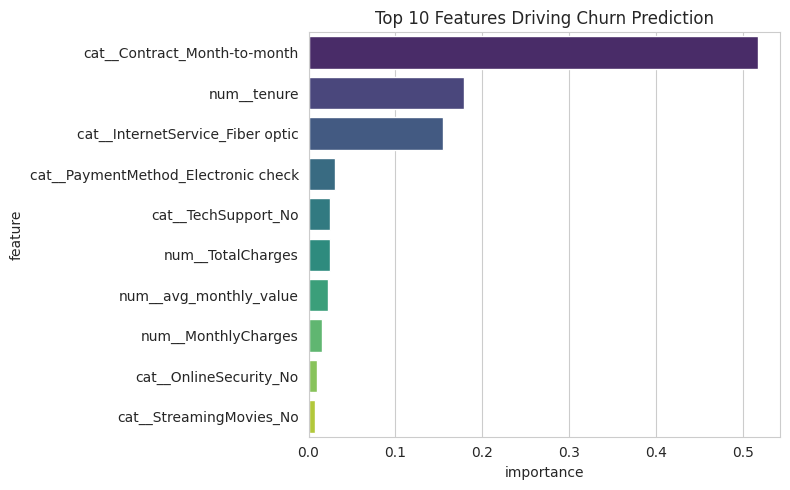

In [32]:
top10 = importances.head(10)
sns.barplot(data=top10, x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features Driving Churn Prediction')
plt.tight_layout()
plt.show()

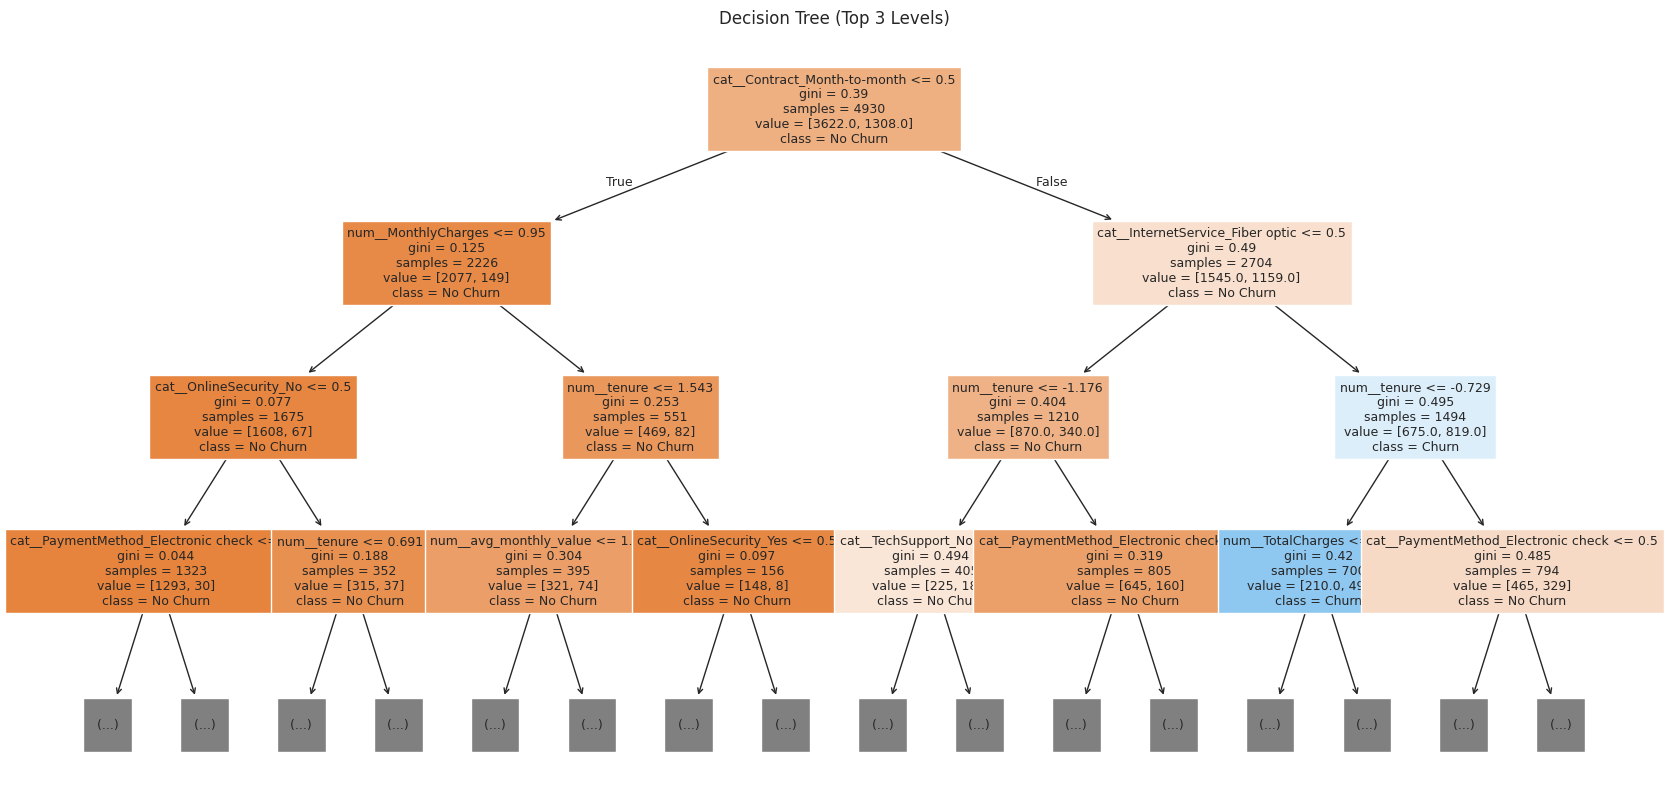

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Decision Tree (Top 3 Levels)')
plt.show()

Contract type is the strongest factor influencing the model's churn predictions. Month-to-month contracts contribute significantly more to the model's decisions than other features.
Other important predictors include low tenure and fiber-optic internet service. Newer customers are more likely to churn, while fiber-optic customers also show a higher churn tendency. Additional factors such as electronic check payments, lack of tech support, and TotalCharges also contribute to the predictions, but to a lesser extent.

Overall, the model identifies a higher-risk customer profile as someone who is relatively new, uses a month-to-month contract, has fiber-optic internet, pays by electronic check, and does not have tech support.
These findings provide useful directions for the business. Retention efforts can focus on customers in their first few months, encourage suitable customers to move from month-to-month to longer-term contracts, and investigate why fiber-optic customers show higher churn.
The engineered Average Monthly Value feature also appeared among the important predictors, suggesting that the feature contributed useful information to the model.
The decision tree visualization supports these findings. The first major split is based on contract type, followed by tenure-related splits, showing that these features play an important role in the model's decisions.

In [34]:
import joblib
joblib.dump(final_model, 'churn_model.pkl')
print("Saved. Pipeline includes preprocessing + model.")

Saved. Pipeline includes preprocessing + model.


In [35]:

input_columns = X_train.columns.tolist()
print(input_columns)
joblib.dump(input_columns, 'input_columns.pkl')

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'total_services', 'avg_monthly_value']


['input_columns.pkl']

In [36]:
engineered = ['tenure_group', 'total_services', 'avg_monthly_value']
raw_input_columns = [c for c in X_train.columns if c not in engineered]
print(raw_input_columns)
joblib.dump(raw_input_columns, 'raw_input_columns.pkl')

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


['raw_input_columns.pkl']